<a href="https://colab.research.google.com/github/Sambarlasagna/ComputerVision_Pytorch/blob/main/ptorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
torch.__version__
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device )

cpu


In [ ]:
#Get data
import requests
import zipfile
from pathlib import Path

#Setup to a data folder
data_path = Path("data/")
image_path = data_path/"pizza_steak_sushi"

#if the image folder doest exist, download it and prepre it....
if image_path.is_dir():
  print(f"{image_path} directory already exists... skipping download")
else:
  print(f"Did not find {image_path} directory,creating one...")
  image_path.mkdir(parents=True,exist_ok = True)

#download pizza,steak and sushi data
with open(data_path / "pizza_steak_sushi.zip","wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading data..")
  f.write(request.content)
#unzip file
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip","r") as zip_ref:
  print("Unziping pizza,steak and sushi data...")
  zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory,creating one...
Unziping pizza,steak and sushi data...


### data prep and exploration


In [ ]:
import os
def walk_through_dir(dir_path):
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")
walk_through_dir(image_path)


There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'


In [ ]:
#setup train and testing paths
train_dir = image_path /"train"
test_dir = image_path/"test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path:data/pizza_steak_sushi/test/sushi/207578.jpg
Image class:sushi
Image height:512
Image width: 382


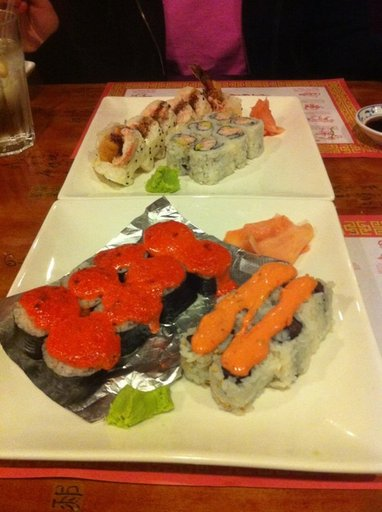

In [ ]:
import random
from PIL import Image

# random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path:{random_image_path}")
print(f"Image class:{image_class}")
print(f"Image height:{img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(381.5), np.float64(511.5), np.float64(-0.5))

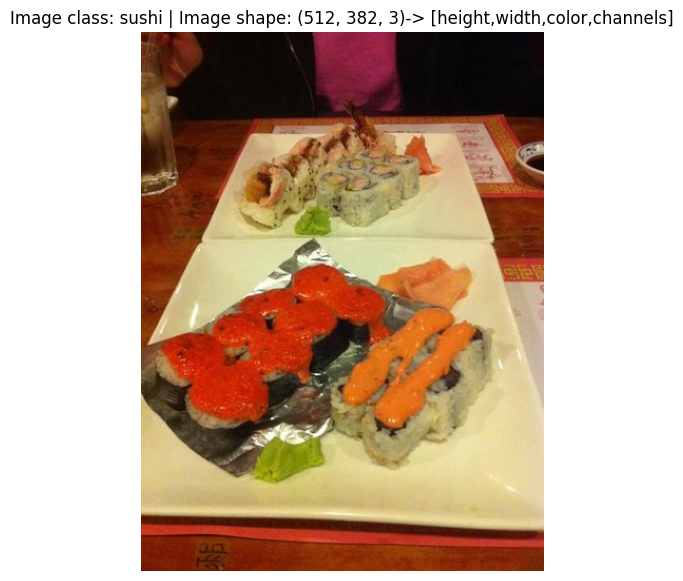

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}-> [height,width,color,channels]")
plt.axis(False)

array([[[111,  42,  11],
        [107,  38,   9],
        [105,  38,  12],
        ...,
        [ 17,   6,  12],
        [ 17,   6,  12],
        [ 16,   5,  11]],

       [[108,  41,  12],
        [103,  38,  10],
        [102,  36,  12],
        ...,
        [ 16,   5,  11],
        [ 16,   5,  11],
        [ 15,   4,  10]],

       [[ 97,  35,  10],
        [ 93,  31,   8],
        [ 92,  30,   9],
        ...,
        [ 16,   5,  11],
        [ 16,   5,  11],
        [ 15,   4,  10]],

       ...,

       [[114,  26,   4],
        [115,  27,   5],
        [113,  25,   3],
        ...,
        [116,  43,  10],
        [114,  41,   8],
        [110,  40,   6]],

       [[112,  24,   4],
        [114,  26,   6],
        [113,  25,   5],
        ...,
        [113,  43,   9],
        [109,  39,   5],
        [105,  37,   2]],

       [[111,  23,   3],
        [113,  25,   5],
        [113,  25,   5],
        ...,
        [111,  41,   7],
        [108,  40,   5],
        [107,  39,   4]]], dtype=uint8)
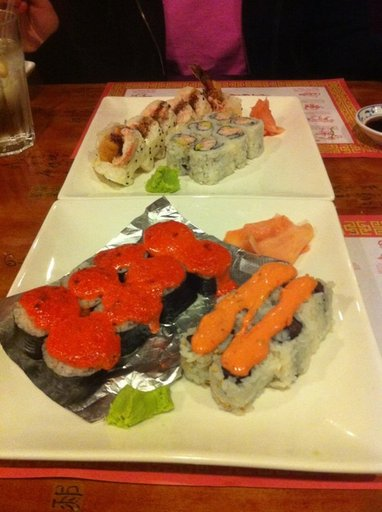

In [ ]:
img_as_array

In [ ]:
#3. Transforming data
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [ ]:
#Write transform for image
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
    ])

In [ ]:
data_transform(img)

tensor([[[0.0667, 0.0627, 0.0471,  ..., 0.3843, 0.3882, 0.3294],
         [0.0667, 0.0627, 0.0431,  ..., 0.3608, 0.4039, 0.4039],
         [0.0667, 0.0627, 0.0431,  ..., 0.3216, 0.3804, 0.4000],
         ...,
         [0.5490, 0.5490, 0.5490,  ..., 0.4902, 0.4824, 0.4824],
         [0.4706, 0.4706, 0.4784,  ..., 0.4863, 0.4784, 0.4784],
         [0.4549, 0.4549, 0.4706,  ..., 0.4706, 0.4588, 0.4510]],

        [[0.0235, 0.0275, 0.0275,  ..., 0.1294, 0.1686, 0.1137],
         [0.0235, 0.0275, 0.0314,  ..., 0.1490, 0.2078, 0.1961],
         [0.0235, 0.0275, 0.0314,  ..., 0.1529, 0.2000, 0.2000],
         ...,
         [0.1843, 0.1725, 0.1725,  ..., 0.1098, 0.1059, 0.1098],
         [0.1608, 0.1529, 0.1569,  ..., 0.1098, 0.1098, 0.1137],
         [0.1608, 0.1569, 0.1608,  ..., 0.1098, 0.1020, 0.1020]],

        [[0.0471, 0.0471, 0.0471,  ..., 0.0627, 0.0980, 0.0471],
         [0.0471, 0.0471, 0.0431,  ..., 0.0745, 0.1059, 0.0980],
         [0.0392, 0.0392, 0.0431,  ..., 0.0745, 0.1059, 0.

In [ ]:
def plot_transformed_images(image_paths: list,transform,n=3,seed=None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}",fontsize=16)

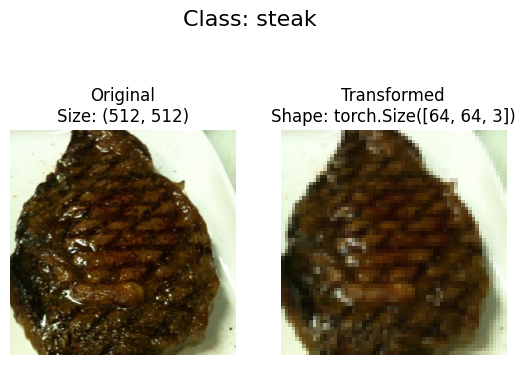

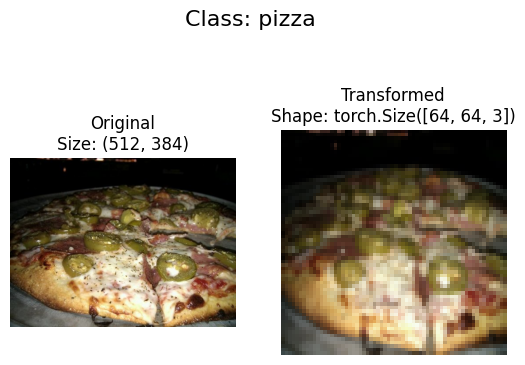

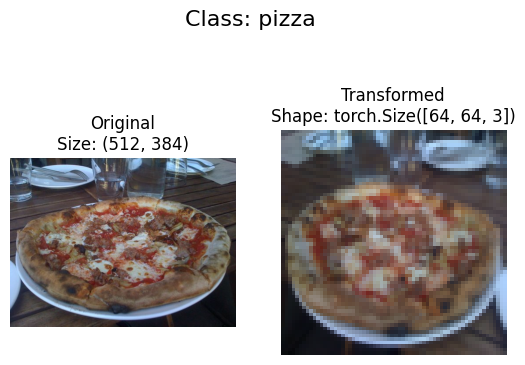

In [ ]:
plot_transformed_images(image_path_list,
                        data_transform,3,42 )

In [ ]:
#use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,transform=data_transform,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform = data_transform)
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names,class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
len(train_data),train_data.samples[0],len(test_data),test_data.samples[0]

(225,
 ('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0),
 75,
 ('data/pizza_steak_sushi/test/pizza/1152100.jpg', 0))

In [ ]:
img,label = train_data[0][0],train_data[0][1]
print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Image class: {class_names[label]}")
print(f"Label datatype: {type(label)}")

Image tensor:
 tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


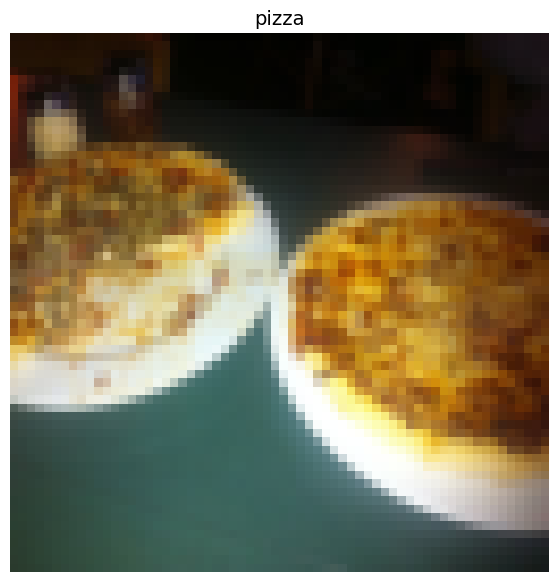

In [ ]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

In [ ]:
import os
os.cpu_count()

2

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader = DataLoader(dataset = train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size =BATCH_SIZE,
                             shuffle=False)
print(len(train_dataloader),len(test_dataloader))
len(train_data),len(test_data)

8 3


(225, 75)

In [ ]:
img,label = next(iter(train_dataloader))
print(f"Image shape: {img.shape} -> [batch_size,color_channels,height,width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size,color_channels,height,width]
Label shape: torch.Size([32])


#3 Loading Image Data with a Custom `Dataset`

In [ ]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict, List



In [ ]:
train_data.classes,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
#5.1 Creatingn a helper function to get class names
target_directory = train_dir
print(f"Target dir: {target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found



Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [ ]:
def find_classes(directory:str)-> Tuple[List[str], Dict[str,int]]:
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}")
  class_to_idx = {cls_name:i for i,cls_name in enumerate(classes)}
  return classes,class_to_idx
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
from torch.utils.data import Dataset
class ImageFolderCustom(Dataset):
    def __init__(self,
                targ_dir:str,transform=None):
     self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
     self.transform = transform
     self.classes,self.class_to_idx = find_classes(targ_dir)

    def load_image(self,index: int)->Image.Image:
      image_path = self.paths[index]
      return Image.open(image_path)

    def __len__(self)->int:
      return len(self.paths)

    def __getitem__(self,index:int)->Tuple[torch.Tensor, int]:
      img = self.load_image(index)
      class_name = self.paths[index].parent.name
      class_idx = self.class_to_idx[class_name]

      if self.transform:
        return self.transform(img), class_idx
      else:
        return img,class_idx


In [ ]:
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [ ]:
train_data_custom = ImageFolderCustom(targ_dir = train_dir,
                                      transform = train_transforms)
test_data_custom = ImageFolderCustom(targ_dir = test_dir,
                                    transform = test_transforms)

In [ ]:
train_data_custom,test_data_custom

(<__main__.ImageFolderCustom at 0x78e3c1bb8a70>,
 <__main__.ImageFolderCustom at 0x78e3c1cb7fe0>)

In [ ]:
len(train_data),len(train_data_custom)

(225, 225)

In [ ]:
len(test_data),len(test_data_custom)

(75, 75)

In [ ]:
test_data_custom.classes,test_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
#Check for equality
print(train_data_custom.classes==train_data.classes)
print(test_data_custom.classes==test_data.classes)

True
True


### 5.3 Create a function to display random images

In [ ]:
#5.3 Create a function to display random images
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes:List[str]=None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int= None):
  if n>10:
    n = 10
    display_shape = False
    print(f"For display, purposes, shudnt be larger than 10, setting to 10 and removign shape display")

  if seed:
    random.seed (seed)

  random_samples_idx = random.sample(range(len(dataset)),k=n)

  plt.figure(figsize=(16,8))

  for i,targ_sample in enumerate(random_samples_idx):
    targ_image,targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    targ_image_adjust = targ_image.permute(1,2,0) #from chw to hwc

    plt.subplot(1,n,i+1) # Changed n/2 to (n+1)//2 to handle odd n
    plt.imshow(targ_image_adjust)
    if classes:
      title = f"Class: {classes[targ_label]}\n"
      if display_shape:
        title = title + f"Shape: {targ_image_adjust.shape}"
      plt.title(title)
      plt.axis("off")

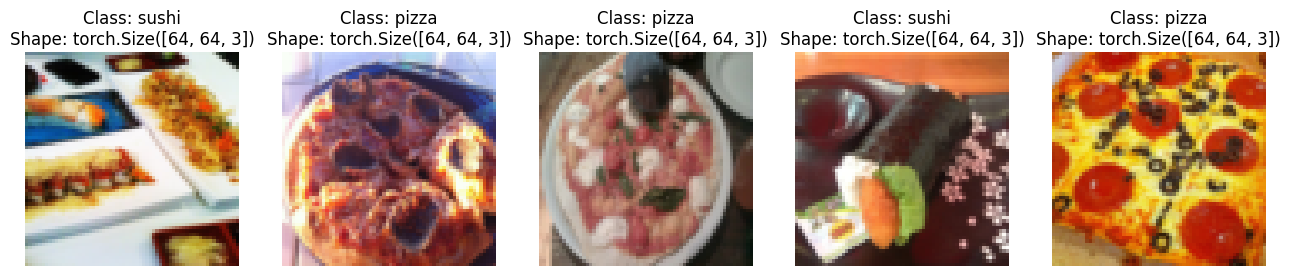

In [ ]:
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=42)


For display, purposes, shudnt be larger than 10, setting to 10 and removign shape display


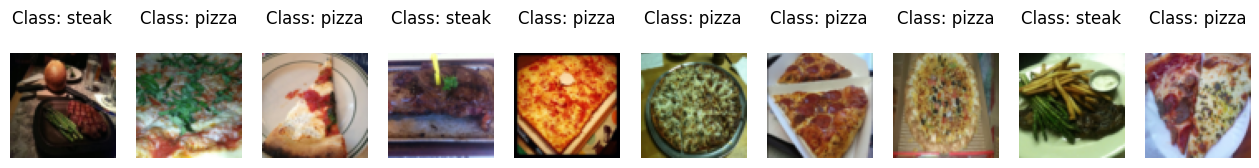

In [ ]:
display_random_images(train_data_custom,
                      n=20,
                      classes=class_names,
                      seed=42)

### 5.4 Turn custom laded images into `DataLoader`'s

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                     batch_size = BATCH_SIZE,
                                     num_workers = NUM_WORKERS,
                                     shuffle = True)
test_dataloader_custom = DataLoader(dataset = test_data_custom,
                                    batch_size = BATCH_SIZE,
                                    num_workers = NUM_WORKERS,
                                    shuffle = False)
train_dataloader_custom,test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x78e3c1395f40>,
 <torch.utils.data.dataloader.DataLoader at 0x78e3c1949640>)

In [ ]:
#Get image and label from customddataloader
img_custom,label_custom = next(iter(train_dataloader_custom))

#print out the shapes
img_custom.shape,label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

### Data augmentation



In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([ transforms.Resize(size=(224,224)),
                                        transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                        transforms.ToTensor()
])
test_transform = transforms.Compose([transforms.Resize(size=(224,224)),
                                      transforms.ToTensor()
])

In [ ]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/pizza/2218680.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2871261.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/971934.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/930553.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2508636.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/344397.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/309892.jpg')]

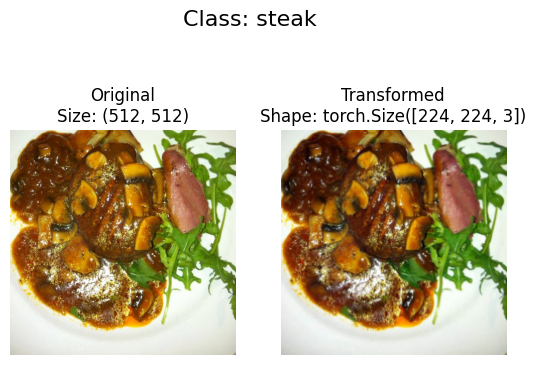

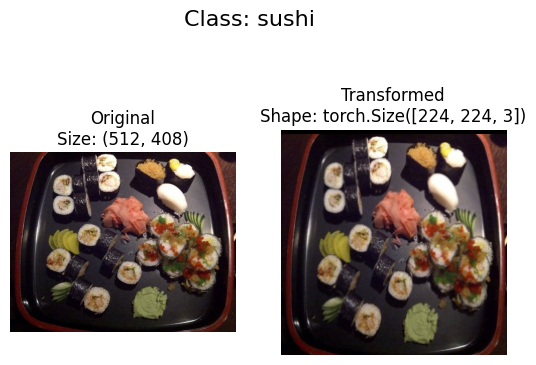

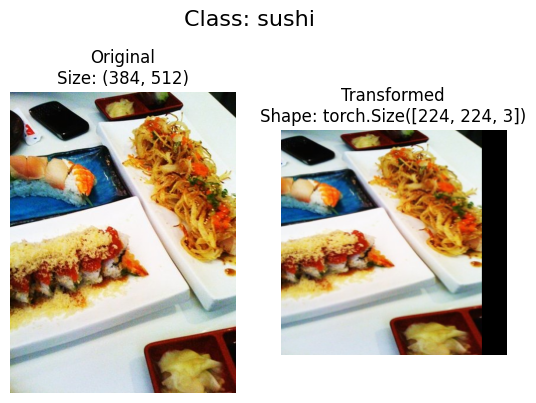

In [ ]:
plot_transformed_images(image_paths = image_path_list,
                          transform = train_transform,
                          n=3,
                          seed=None)

#7 : Model 0- TinyVGG withotu data augmentation
https://poloclub.github.io/cnn-explainer/

In [ ]:
#7.1 Creating transforms and llading data for Model 0
from torchvision import transforms
simple_transform = transforms.Compose([transforms.Resize(size=(64,64)),
                                       transforms.ToTensor()
])

In [ ]:
#load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform = simple_transform)
#turn the datasets into DataLoaders
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

#create dataLoader's
train_dataloader_simple = DataLoader(dataset = train_data_simple,
                                     batch_size = BATCH_SIZE,
                                     shuffle = True,
                                     num_workers = NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                     batch_size = BATCH_SIZE,
                                     shuffle = False,
                                     num_workers = NUM_WORKERS)

### 7.2 Create TinyVGG model class


In [ ]:
class TinyVGG(nn.Module):
  def __init__(self,input_shape: int,
               hidden_units: int,
               output_shape:int)->None:
      super().__init__()
      self.conv_block_1 = nn.Sequential(
          nn.Conv2d(in_channels =input_shape,
                    out_channels =hidden_units,
                    kernel_size = 3,
                    stride = 1,
                    padding = 0),
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size = 3,
                    stride  =1,
                    padding = 0 ),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size = 2,
                       stride = 2),
      )
      self.conv_block_2 = nn.Sequential(
          nn.Conv2d(in_channels =hidden_units,
                    out_channels =hidden_units,
                    kernel_size = 3,
                    stride = 1,
                    padding = 0),
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size = 3,
                    stride  =1,
                    padding = 0 ),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size = 2,
                       stride = 2)
      )
      self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features = hidden_units*13*13,
                    out_features = output_shape)
      )

  def forward(self,x):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)
    return x
    # return self.classifier(self.conv_block_2(self.conv_block_1(x)))


In [ ]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape = 3, #number of colour channels
                  hidden_units = 10,
                  output_shape = len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [ ]:
# 7.3 try a forward a pass on a single image to test the model
image_batch,label_batch = next(iter(train_dataloader_simple))
image_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
#try a forward pass
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4668e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9131e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6415e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7979e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1816e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3995e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.1665e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

In [ ]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torch

In [ ]:
from torchinfo import summary
summary(model_0,input_size = (1,3,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

### 7.5 create train and test loop funcs


In [ ]:
from re import L
def train_step(model : torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device : torch.device = device):
  model.train()
  train_loss,train_acc = 0,0
  model.to(device)
  for batch,(X,y) in enumerate (data_loader):
    X, y = X.to(device), y.to(device)

    #forward pass
    y_pred = model(X)

    #calc loss
    loss=loss_fn(y_pred,y)
    train_loss +=loss.item()

    #optimizer zero grad
    optimizer.zero_grad()

    #loss backward
    loss.backward()

    #optimizer step
    optimizer.step()

    #calc accuracy metric
    y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
    train_acc +=(y_pred_class==y).sum().item()/len(y_pred)

  #calc loss and acc per epoch and print out whats happeneing
  train_loss /=len(data_loader)
  train_acc /=len(data_loader)
  return train_loss,train_acc

def test_step(data_loader: torch.utils.data.DataLoader,
              model:torch.nn.Module,
              loss_fn: torch.nn.Module,
              device: torch.device = device):
  test_loss,test_acc = 0,0
  model.to(device)
  model.eval()

  with torch.inference_mode():

    for X,y in data_loader:
      X,y = X.to(device),y.to(device)

      #forward pass
      test_pred = model(X)

      #calc loss
      loss = loss_fn(test_pred,y)
      test_loss+=loss.item()

      #calc acc
      test_pred_labels = test_pred.argmax(dim=1)
      test_acc += ((test_pred_labels==y).sum().item()/len(test_pred_labels))

    #adjust metrics and print out
    test_loss/=len(data_loader)
    test_acc /=len(data_loader)
    return test_loss,test_acc

### 7.6 creating `train()` func to combine `train_step()` and `test_step()`

In [ ]:
from tqdm.auto import tqdm
#create a func that takes in  various model parameters
def train(model:torch.nn.Module,
          train_dataloader:torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn =nn.CrossEntropyLoss(),
          epochs: int = 5,
          device=device):
  #create empty results dict
  results = {"train_loss":[],
             "train_acc":[],
             "test_loss":[],
             "test_acc":[]}
  #loop thru train and test steps for a number of steps
  for epoch in tqdm(range(epochs)):
    train_loss,train_acc = train_step(model = model,
                                      data_loader = train_dataloader,
                                      loss_fn = loss_fn,
                                      optimizer = optimizer,
                                      device = device)
    test_loss,test_acc = test_step(data_loader = test_dataloader,
                                   model = model,
                                   loss_fn = loss_fn,
                                   device = device)
    #print out
    print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    #update results dict
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)

    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

### 7.7 train and evaluate model 0


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set no. of epochs
NUM_EPOCHS = 5

#Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape = 3,
                  hidden_units = 10,
                  output_shape = len(train_data.classes)).to(device)
#setup loss func and optim
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr = 0.001) # Reduced learning rate

#start the timer
from timeit import default_timer as timer
start_time = timer()

#trai model_0
model_0_results = train(model = model_0,
                        train_dataloader = train_dataloader_simple,
                        test_dataloader = test_dataloader_simple,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS)
#end timer and print
end_time = timer()
print(f"Total training time: {end_time-start_time: .3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.1063 | Train Acc: 0.3047 | Test Loss: 1.0983 | Test Acc: 0.3011
Epoch: 1 | Train Loss: 1.0998 | Train Acc: 0.3281 | Test Loss: 1.0697 | Test Acc: 0.5417
Epoch: 2 | Train Loss: 1.0869 | Train Acc: 0.4883 | Test Loss: 1.0808 | Test Acc: 0.4924
Epoch: 3 | Train Loss: 1.0842 | Train Acc: 0.3984 | Test Loss: 1.0608 | Test Acc: 0.5833
Epoch: 4 | Train Loss: 1.0662 | Train Acc: 0.4141 | Test Loss: 1.0654 | Test Acc: 0.5644
Total training time:  16.200 seconds


In [ ]:
model_0_results

{'train_loss': [1.106319084763527,
  1.0998057276010513,
  1.0868544578552246,
  1.0842333287000656,
  1.0662163645029068],
 'train_acc': [0.3046875, 0.328125, 0.48828125, 0.3984375, 0.4140625],
 'test_loss': [1.0983205238978069,
  1.069690187772115,
  1.0807572205861409,
  1.0608318249384563,
  1.0653960307439168],
 'test_acc': [0.30113636363636365,
  0.5416666666666666,
  0.49242424242424243,
  0.5833333333333334,
  0.5643939393939394]}

### 7.8 plot the loss curves od model 0


In [ ]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [ ]:
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results : Dict[str,List[float]]):
  #get thr loss vlaues frm the res dict
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  #setup a plot

  plt.figure(figsize=(15,7))

  #plot loss

  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label = "train_loss")
  plt.plot(epochs,test_loss,label = "test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  #plot accuracy
  plt.subplot(1,2,2)
  plt.plot(epochs,accuracy,label = "train_accuracy")
  plt.plot(epochs,test_accuracy,label = "test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

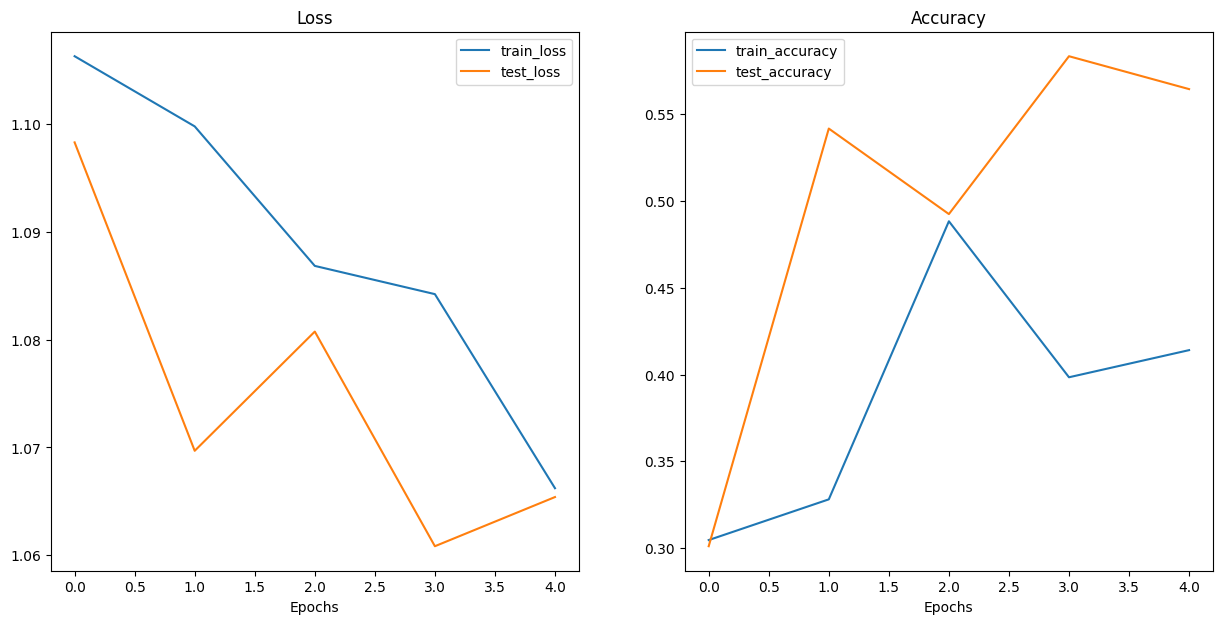

In [ ]:
plot_loss_curves(model_0_results)

### Model 1: TinyVGG with dataa augmentation


In [ ]:
### 9.1 create transform with data aug
from torchvision import transforms
train_transform_trivial = transforms.Compose([transforms.Resize(size=(64,64)),
                                              transforms.TrivialAugmentWide(num_magnitude_bins = 31),
                                              transforms.ToTensor()])
test_transform_simple= transforms.Compose([transforms.Resize(size=(64,64)),
                                             transforms.ToTensor()])


In [ ]:
# 9.2 create train and test Dataseta dn Dataloaders with data aug
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform = train_transform_trivial)
test_data_augmented = datasets.ImageFolder(root=test_dir,
                                           transform = test_transform_simple)

In [ ]:
#turn datasets into dataloaders
import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_data_augmented,
                                        batch_size = BATCH_SIZE,
                                        shuffle = True,
                                        num_workers = NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                    batch_size = BATCH_SIZE,
                                    num_workers = NUM_WORKERS)

In [ ]:
#9.3 contruct and train model 1
model_1 = TinyVGG(input_shape =3,
                   hidden_units =10,
                   output_shape = len(train_data_augmented.classes)).to(device)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()
optimizer =  torch.optim.Adam(params = model_1.parameters(),
                              lr = 0.001)
from timeit import default_timer as timer
start_time = timer()

model_1_results = train(model = model_1,
                        train_dataloader = train_dataloader_augmented,
                        test_dataloader = test_dataloader_simple,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS,
                        device = device)
end_time = timer()
print(f"Total training time: {end_time-start_time: .3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.1049 | Train Acc: 0.2500 | Test Loss: 1.1019 | Test Acc: 0.2604
Epoch: 1 | Train Loss: 1.0807 | Train Acc: 0.4258 | Test Loss: 1.1261 | Test Acc: 0.2604
Epoch: 2 | Train Loss: 1.0712 | Train Acc: 0.4258 | Test Loss: 1.1593 | Test Acc: 0.2604
Epoch: 3 | Train Loss: 1.1253 | Train Acc: 0.3047 | Test Loss: 1.1581 | Test Acc: 0.2604
Epoch: 4 | Train Loss: 1.0865 | Train Acc: 0.4258 | Test Loss: 1.1554 | Test Acc: 0.3333
Total training time:  8.739 seconds


In [ ]:
model_1_results

{'train_loss': [1.104914203286171,
  1.0806865319609642,
  1.0711720064282417,
  1.125308334827423,
  1.0865339040756226],
 'train_acc': [0.25, 0.42578125, 0.42578125, 0.3046875, 0.42578125],
 'test_loss': [1.1019279559453328,
  1.1260557969411213,
  1.159274657567342,
  1.1580672065416973,
  1.1554409265518188],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.3333333333333333]}

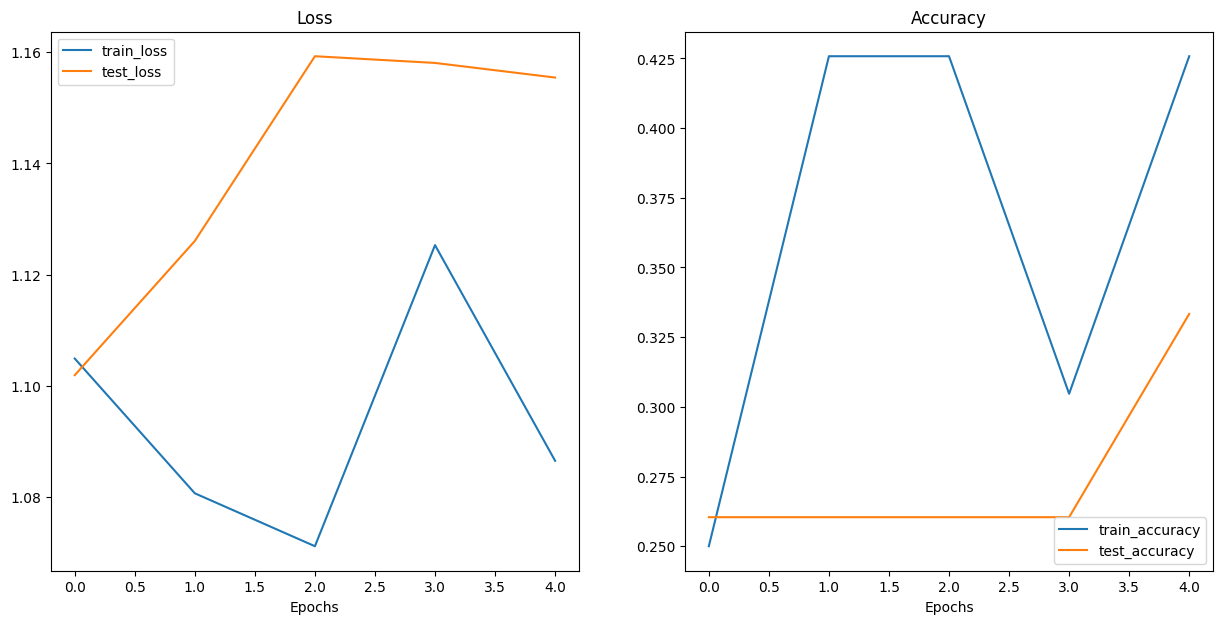

In [ ]:
#plot the loss curves
plot_loss_curves(model_1_results)

### Compare model results

In [ ]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.106319,0.304688,1.098321,0.301136
1,1.099806,0.328125,1.069690,0.541667
2,1.086854,0.488281,1.080757,0.492424
3,1.084233,0.398438,1.060832,0.583333
4,1.066216,0.414062,1.065396,0.564394


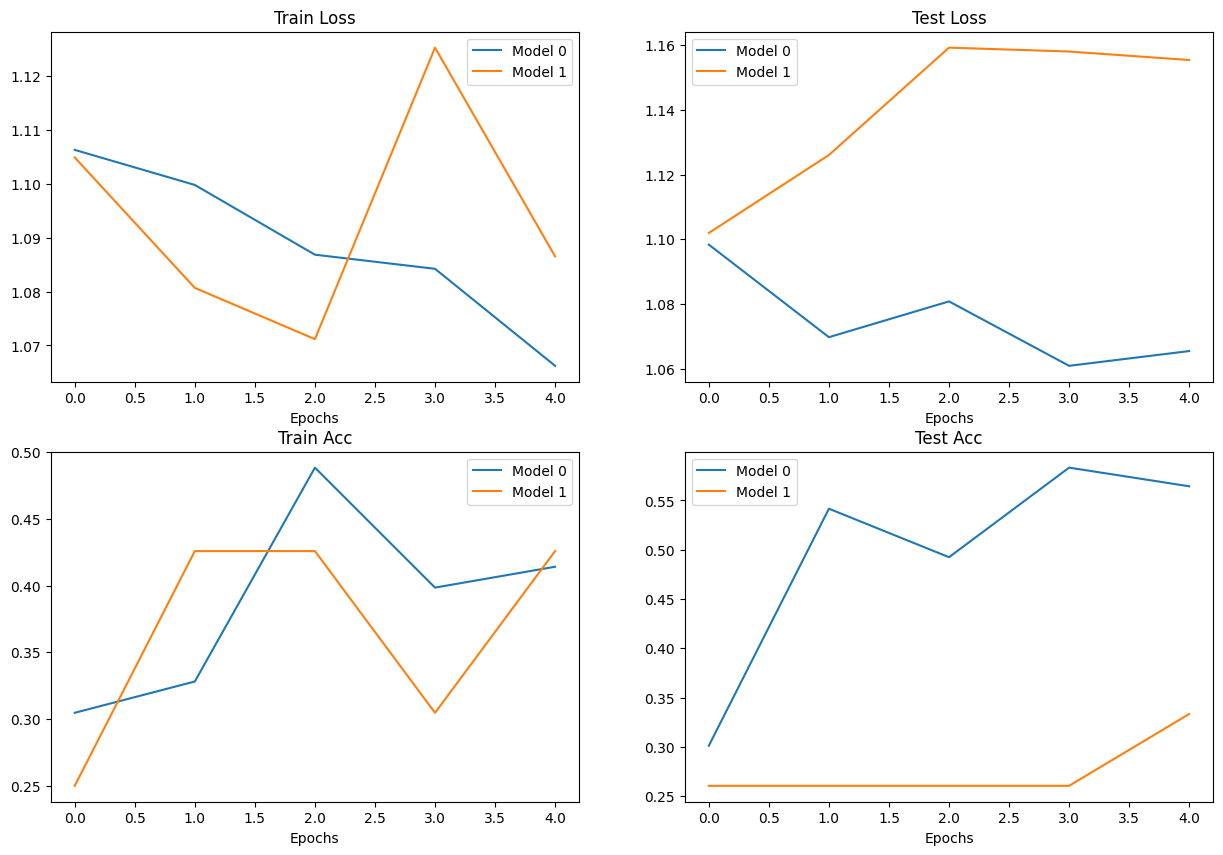

In [89]:
#Plot
plt.figure(figsize=(15,10))

#Get number fo epochs
epochs = range(len(model_0_df))

plt.subplot(2,2,1)
plt.plot(epochs,model_0_df["train_loss"],label = "Model 0")
plt.plot(epochs,model_1_df["train_loss"],label = "Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,2)
plt.plot(epochs,model_0_df["test_loss"],label = "Model 0")
plt.plot(epochs,model_1_df["test_loss"],label = "Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,3)
plt.plot(epochs,model_0_df["train_acc"],label = "Model 0")
plt.plot(epochs,model_1_df["train_acc"],label = "Model 1")
plt.title("Train Acc")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,4)
plt.plot(epochs,model_0_df["test_acc"],label = "Model 0")
plt.plot(epochs,model_1_df["test_acc"],label = "Model 1")
plt.title("Test Acc")
plt.xlabel("Epochs")
plt.legend()


### 11. Making a prediction on a custom image

tensor of dtype torch.float32

of shape 64x64x3

on the right device

In [90]:
#Doanload custom image

custom_image_path = data_path/"pizza.jpg"
print(f"Custom image path: {custom_image_path}")



Custom image path: data/pizza.jpg


In [96]:
# 11.1 loading in cusotm image with pytorch
import torchvision
custom_image_uint8 = torchvision.io.read_image(custom_image_path)
print(f"Custom image tensor:\n {custom_image_uint8}")
print(f"Custom image shape: {custom_image_uint8.shape}")
print(f"Custom image datatype : {custom_image_uint8.dtype}")

Custom image tensor:
 tensor([[[202, 189, 199,  ..., 245, 239, 237],
         [211, 178, 171,  ..., 242, 238, 241],
         [201, 200, 187,  ..., 240, 236, 244],
         ...,
         [247, 247, 247,  ..., 189, 188, 238],
         [247, 247, 247,  ..., 215, 179, 196],
         [247, 247, 247,  ..., 219, 227, 198]],

        [[126, 113, 123,  ...,  50,  39,  34],
         [135, 102,  95,  ...,  48,  40,  41],
         [125, 124, 111,  ...,  51,  42,  46],
         ...,
         [250, 250, 250,  ..., 122, 119, 170],
         [250, 250, 250,  ..., 145, 109, 126],
         [250, 250, 250,  ..., 146, 154, 125]],

        [[ 42,  29,  39,  ...,  48,  41,  37],
         [ 51,  18,  11,  ...,  46,  41,  43],
         [ 41,  40,  27,  ...,  49,  42,  47],
         ...,
         [255, 255, 255,  ...,  52,  50,  99],
         [255, 255, 255,  ...,  76,  40,  57],
         [255, 255, 255,  ...,  78,  86,  57]]], dtype=torch.uint8)
Custom image shape: torch.Size([3, 510, 680])
Custom image dataty

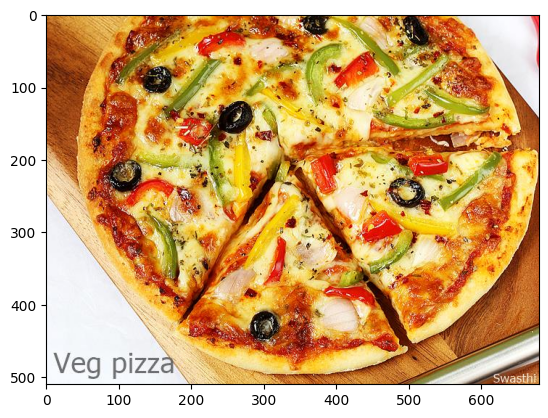

In [94]:
plt.imshow(custom_image_uint8.permute(1,2,0))

In [111]:
# 11.2 makign a predn
#make the image to right dtype and device
custom_image = custom_image_uint8.to(device,dtype = torch.float32)/255

#divide by 255 to get the value between 0 to 255
custom_image

tensor([[[0.7922, 0.7412, 0.7804,  ..., 0.9608, 0.9373, 0.9294],
         [0.8275, 0.6980, 0.6706,  ..., 0.9490, 0.9333, 0.9451],
         [0.7882, 0.7843, 0.7333,  ..., 0.9412, 0.9255, 0.9569],
         ...,
         [0.9686, 0.9686, 0.9686,  ..., 0.7412, 0.7373, 0.9333],
         [0.9686, 0.9686, 0.9686,  ..., 0.8431, 0.7020, 0.7686],
         [0.9686, 0.9686, 0.9686,  ..., 0.8588, 0.8902, 0.7765]],

        [[0.4941, 0.4431, 0.4824,  ..., 0.1961, 0.1529, 0.1333],
         [0.5294, 0.4000, 0.3725,  ..., 0.1882, 0.1569, 0.1608],
         [0.4902, 0.4863, 0.4353,  ..., 0.2000, 0.1647, 0.1804],
         ...,
         [0.9804, 0.9804, 0.9804,  ..., 0.4784, 0.4667, 0.6667],
         [0.9804, 0.9804, 0.9804,  ..., 0.5686, 0.4275, 0.4941],
         [0.9804, 0.9804, 0.9804,  ..., 0.5725, 0.6039, 0.4902]],

        [[0.1647, 0.1137, 0.1529,  ..., 0.1882, 0.1608, 0.1451],
         [0.2000, 0.0706, 0.0431,  ..., 0.1804, 0.1608, 0.1686],
         [0.1608, 0.1569, 0.1059,  ..., 0.1922, 0.1647, 0.

In [113]:
#create transform pipeline to resize image
from torchvision import transforms
custom_image_transform = transforms.Compose({
    transforms.Resize(size = (64,64))
})
custom_image_transformed = custom_image_transform(custom_image)
print(f"Original shape: {custom_image.shape}")
print(f"Transformed shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 510, 680])
Transformed shape: torch.Size([3, 64, 64])


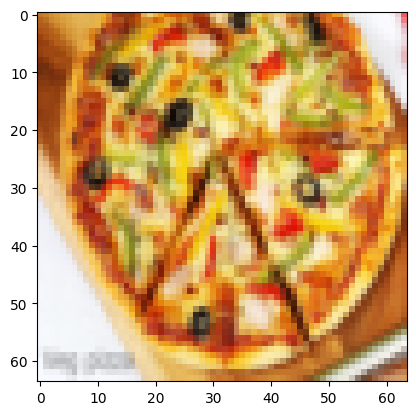

In [128]:
plt.imshow(custom_image_transformed.permute(1,2,0))

AxesImage(shape=(510, 680, 3))
Prediction label: pizza


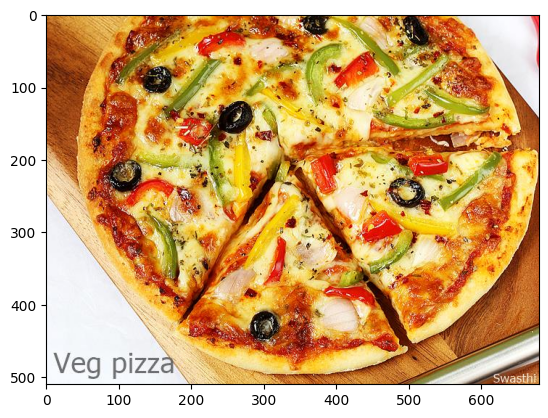

In [130]:
#now the size is 3,64,64 but our prediction was in batches (x,3,64,64)
#hence unsqueezr in dim 0
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(0))

#convert logits to probablities
custom_image_pred_probs = torch.softmax(custom_image_pred,dim=1)

#convert predn prob to labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs,dim=1)
predicted_label = class_names[custom_image_pred_label]
print(plt.imshow(custom_image_uint8.permute(1,2,0)))
print(f"Prediction label: {predicted_label}")


### 11.3 Pytting cusotm image predn together : building a function

In [169]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names : List[str] = None,
                        transform = None,
                        device:torch.device = device):
  #convert image to tensor
  custom_image_uint8 = torchvision.io.read_image(image_path)

  if transform:
    custom_image_transformed = transform(custom_image_uint8)

  #convert to right dtype and device and make it bw 0 to 1
  custom_image_transformed = custom_image_transformed.to(device,dtype = torch.float32)/255

  #make predn
  model.eval()
  with torch.inference_mode():
    model.to(device)
    custom_image_pred = model(custom_image_transformed.unsqueeze(0)) # convert shape to include batch size dimension

  custom_image_pred_probs = torch.softmax(custom_image_pred,dim = 1)

  custom_image_pred_label = torch.argmax(custom_image_pred_probs,dim=1).cpu()

  predicted_label = class_names[custom_image_pred_label]
  plt.imshow(custom_image_transformed.permute(1,2,0)) # make sure it's the right size for matplotlib
  if class_names:
      title = f"Pred: {predicted_label} | Prob: {custom_image_pred_probs.max().cpu():.3f}"
  else:
      title = f"Pred: {custom_image_pred_label} | Prob: {custom_image_pred_probs.max().cpu():.3f}"
  plt.title(title)
  plt.axis(False);

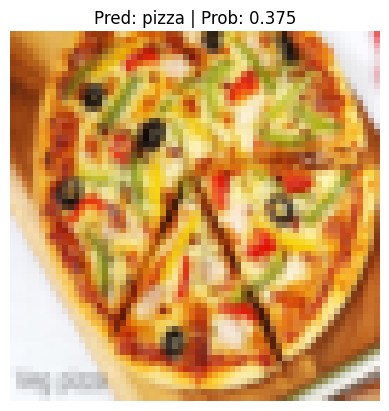

In [170]:
#predict
pred_and_plot_image(model = model_1,
                    image_path = custom_image_path,
                    class_names = class_names,
                    transform = custom_image_transform,
                    device = device)